In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Background
***Part1***.An e-commerce platform is planning a promotional campaign by sending advertisements and discount information via SMS to potential users, aiming to attract them to register on the platform and make purchases.

We now have three datasets:

1. user_behavior_time_resampled.csv: User behavior table
2. vip_user.csv: VIP membership table
3. user_info.csv: User information table

The goals of this part:

1. Identify the characteristics of the people who are most likely to convert through data analysis. (age, gender, location...) 
2. Determine the most effective time to send marketing SMS for conversion through data analysis.

***Part2***. Within the three days leading up to the start of the promotion, users can only browse products or add them to their shopping cart, but cannot place orders. They can participate in the flash sale and place orders after the three-day period.

The goal of this part:\
Based on user behavior during the three-day warm-up period, we can predict the sales volume of each product to avoid issues with insufficient stock from suppliers.

# Part 1

## Step 1: Import the dataset

In [2]:
df_user_log = pd.read_csv('user_behavior_time_resampled.csv')
df_vip_user = pd.read_csv('vip_user.csv')
df_user_info = pd.read_csv('user_info.csv')

------

In [3]:
df_user_log
### user_id:     ID d'un utilisateur, identification unique pour un utilisateur
### item_id:     ID d'un produit, identification unique pour un produit
### cat_id:      ID de catégorie, identification unique pour la catégorie d'un produit
### seller_id:   Seller ID, l'identification unique du vendeur
### brand_id:    Brand ID, l'identité unique de la marque
### time_stamp:  L’heure à laquelle le comportement s’est produit
### action_type: Type de comportement:
###                 · click: cliquez sur produits
###                 · cart: Ajouter au panier
###                 · order: Passer une commande
###                 · fav: Ajouter à la liste de souhaits
### timestamp:   L’heure à laquelle le comportement s’est produit

,user_id,item_id,cat_id,seller_id,brand_id,time_stamp,action_type,timestamp
0,328862,323294,833,2882,2661.0,829,click,62242.300959
1,328862,623866,1271,2882,2661.0,829,click,75598.841378
2,328862,239288,602,420,4953.0,801,click,69606.479645
3,328862,197239,602,420,4953.0,801,click,62758.912202
4,328862,524981,664,2382,1272.0,602,click,39651.123222
...,...,...,...,...,...,...,...,...
10985061,208016,869502,898,3716,5508.0,1110,click,58128.784724
10985062,208016,51712,898,3763,8434.0,1110,click,84907.294322
10985063,208016,952056,898,3763,8434.0,1110,click,64118.247166
10985064,208016,952056,898,3763,8434.0,1110,click,18877.391838


In [4]:
## la différence entre time_stamp et timestamp
time_stamp_max = str(df_user_log['time_stamp'].max())
time_stamp_min = str(df_user_log['time_stamp'].min())
print("time_stamp max:" + time_stamp_max, "time_stamp min:" + time_stamp_min)

timestamp_max = str(df_user_log['timestamp'].max())
timestamp_min = str(df_user_log['timestamp'].min())
print("timestamp_max:" + timestamp_max, "timestamp_min:" + timestamp_min)


###  time_stamp: Cela représente la date à laquelle l’action a eu lieu. （511=11/05; 1112=12/11)
###  timestamp:  Cela indique à quelle seconde de la journée l’action a eu lieu.

time_stamp max:1112 time_stamp min:511
timestamp_max:86399.99327792758 timestamp_min:0.1078739773348047


In [5]:
df_user_log.rename(columns={'time_stamp':'date'}, inplace=True)
df_user_log

,user_id,item_id,cat_id,seller_id,brand_id,date,action_type,timestamp
0,328862,323294,833,2882,2661.0,829,click,62242.300959
1,328862,623866,1271,2882,2661.0,829,click,75598.841378
2,328862,239288,602,420,4953.0,801,click,69606.479645
3,328862,197239,602,420,4953.0,801,click,62758.912202
4,328862,524981,664,2382,1272.0,602,click,39651.123222
...,...,...,...,...,...,...,...,...
10985061,208016,869502,898,3716,5508.0,1110,click,58128.784724
10985062,208016,51712,898,3763,8434.0,1110,click,84907.294322
10985063,208016,952056,898,3763,8434.0,1110,click,64118.247166
10985064,208016,952056,898,3763,8434.0,1110,click,18877.391838


------

In [6]:
df_vip_user

### user_id:      ID d'un utilisateur, identification unique pour un utilisateur
### merchant_id:  Seller ID, l'identification unique du vendeur
### label:        Indique si l’utilisateur est un client VIP du marchand mentionné ci-dessus

,user_id,merchant_id,label
0,34176,3906,0
1,34176,121,0
2,34176,4356,1
3,34176,2217,0
4,230784,4818,0
...,...,...,...
260859,359807,4325,0
260860,294527,3971,0
260861,294527,152,0
260862,294527,2537,0


-----

In [7]:
df_user_info

### user_id:    ID d'un utilisateur, identification unique pour un utilisateur
### age_range:  Tranche d’âge, cela répartissent principalement comme suit:
###                    · 1, âge < 18
###                    · 2, 18 < âge < 24
###                    · 3, 25 < âge < 29
###                    · 4, 30 < âge < 34
###                    · 5, 35 < âge < 39
###                    · 6, 40 < âge < 49
###                    · 7/8, 50 < âge
###                    · 0 ou null, on ne sait pas
### gender:     Le genre de l'utilisateur:
###                    · 0: femme
###                    · 1: homme
###                    · 2: on ne sait pas


,user_id,age_range,gender
0,376517,6.0,1.0
1,234512,5.0,0.0
2,344532,5.0,0.0
3,186135,5.0,0.0
4,30230,5.0,0.0
...,...,...,...
424165,395814,3.0,1.0
424166,245950,0.0,1.0
424167,208016,NaN,NaN
424168,272535,6.0,1.0


<hr style="border:1px dashed black;">

## Step2 Data Cleaning

### Handle the missing values in df_user_log.

In [8]:
df_user_log.isnull().sum()

user_id            0
item_id            0
cat_id             0
seller_id          0
brand_id       18132
date               0
action_type        0
timestamp          0
dtype: int64

There are 18,132 records without a brand_id. Since this represents a very small proportion, we choose not to handle them for now.

------

### Traiter les valeurs manquantes dans df_user_info

In [9]:
df_user_info.isnull().sum()

user_id         0
age_range    2217
gender       6436
dtype: int64

2,217 records lack age information, and 6,436 records are missing gender information. Since these proportions are relatively small, we will remove these records from the dataset.

In [10]:
df_user_info = df_user_info.dropna()
df_user_info

,user_id,age_range,gender
0,376517,6.0,1.0
1,234512,5.0,0.0
2,344532,5.0,0.0
3,186135,5.0,0.0
4,30230,5.0,0.0
...,...,...,...
424164,297789,0.0,1.0
424165,395814,3.0,1.0
424166,245950,0.0,1.0
424168,272535,6.0,1.0


In [11]:
print(df_user_info.loc[df_user_info["age_range"]==0.0, ["user_id"]].shape)
print(df_user_info.loc[df_user_info["gender"]==0.0, ["user_id"]].shape)

(90638, 1)
(285634, 1)


As long as either age or gender is provided, the analysis of the related data remains relevant. Therefore, we choose to keep these records for now.

----

In [12]:
df_vip_user.isnull().sum()

user_id        0
merchant_id    0
label          0
dtype: int64

## Step 3: Data analysis of individual user attributes

### Analysis of the age distribution of users

In [13]:
df_user_info.age_range.value_counts()

3.0    110952
0.0     90638
4.0     79649
2.0     52420
5.0     40601
6.0     35257
7.0      6924
8.0      1243
1.0        24
Name: age_range, dtype: int64

In [14]:
## Calculer la proportion des utilisateurs âgés de 25 à 34 ans 

user_ages = df_user_info.loc[df_user_info["age_range"] != 0, "age_range"]
user_ages.loc[(user_ages==3)|(user_ages==4)].shape[0]/user_ages.shape[0]

0.5827529275078729

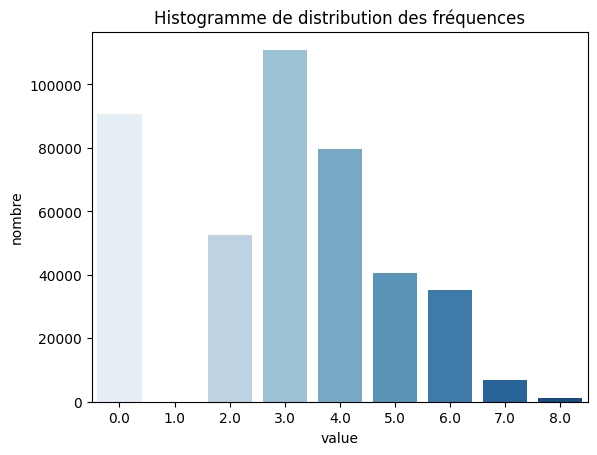

In [15]:
## plot
sns.countplot(x='age_range', data=df_user_info, palette='Blues')
plt.title('Histogramme de distribution des fréquences')
plt.xlabel('value')
plt.ylabel('nombre')
plt.show()

------

### Analysis of the gender distribution of users

In [16]:
df_user_info.gender.value_counts()

0.0    285634
1.0    121655
2.0     10419
Name: gender, dtype: int64

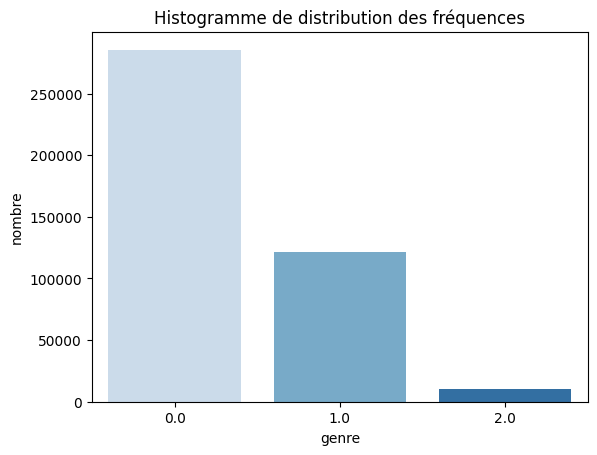

In [17]:
## plot
sns.countplot(x='gender', data=df_user_info, palette='Blues')
plt.title('Histogramme de distribution des fréquences')
plt.xlabel('genre')
plt.ylabel('nombre')
plt.show()

We can observe that the main user group of this shopping platform is female, with their number being more than twice that of males. However, there is still a possibility that although the number of registered male users is lower, their purchasing power is stronger than that of females.

<hr style="border:1px dashed black;">

## Data analysis of user group behavior
We want to analyze the ordering behavior characteristics of different user groups. The order volume is in the user_log table, while user information is in the user_info table. Therefore, we aim to merge the two tables using the common field user_id.

In [18]:
# Merge user_log and user_info
df_user_log = df_user_log.join(df_user_info.set_index('user_id'), on='user_id')
df_user_log

,user_id,item_id,cat_id,seller_id,brand_id,date,action_type,timestamp,age_range,gender
0,328862,323294,833,2882,2661.0,829,click,62242.300959,6.0,1.0
1,328862,623866,1271,2882,2661.0,829,click,75598.841378,6.0,1.0
2,328862,239288,602,420,4953.0,801,click,69606.479645,6.0,1.0
3,328862,197239,602,420,4953.0,801,click,62758.912202,6.0,1.0
4,328862,524981,664,2382,1272.0,602,click,39651.123222,6.0,1.0
...,...,...,...,...,...,...,...,...,...,...
10985061,208016,869502,898,3716,5508.0,1110,click,58128.784724,NaN,NaN
10985062,208016,51712,898,3763,8434.0,1110,click,84907.294322,NaN,NaN
10985063,208016,952056,898,3763,8434.0,1110,click,64118.247166,NaN,NaN
10985064,208016,952056,898,3763,8434.0,1110,click,18877.391838,NaN,NaN


### Analysis of ordering behavior across different age groups

In [19]:
df_user_log.loc[df_user_log["action_type"] == "order", ["age_range"]].age_range.value_counts()

3.0    172525
4.0    153795
0.0    114908
5.0     79298
6.0     61534
2.0     59072
7.0     10785
8.0      1924
1.0        21
Name: age_range, dtype: int64

In [20]:
sr_order_age = df_user_log.loc[df_user_log["action_type"] == "order", ["age_range"]].age_range.value_counts()
(sr_order_age[3]+sr_order_age[4])/(sum(sr_order_age)-sr_order_age[0])

0.6054691123917811

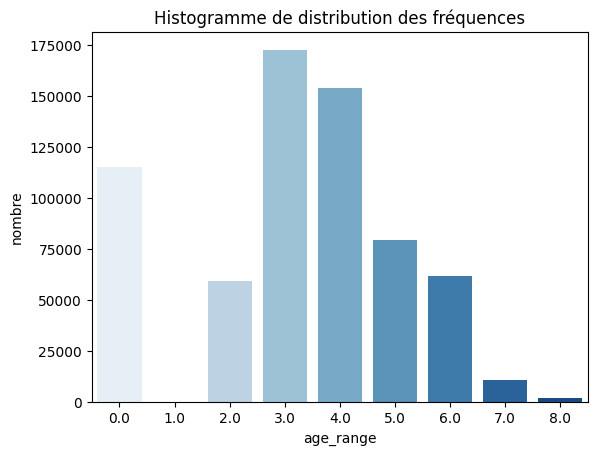

In [21]:
# plot
df_order_user = df_user_log.loc[df_user_log["action_type"] == "order", ["age_range"]].age_range.value_counts().reset_index()
sns.barplot(x=df_order_user['index'], y=df_order_user['age_range'], data=df_order_user, palette='Blues')
plt.title('Histogramme de distribution des fréquences')
plt.xlabel('age_range')
plt.ylabel('nombre')
plt.show()

People aged 25–34 remain the main group placing orders.

------

### Analysis of Ordering Behavior by Users of Different Genders

In [22]:
df_user_log.loc[df_user_log['action_type']=="order", ["gender"]].gender.value_counts()

0.0    467381
1.0    161999
2.0     24482
Name: gender, dtype: int64

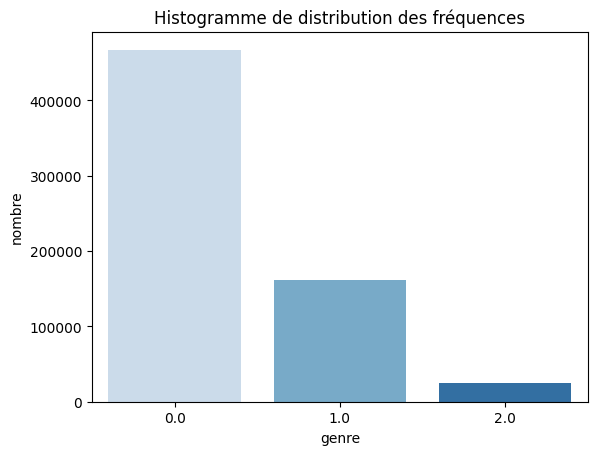

In [23]:
## plot
df_order_gender = df_user_log.loc[df_user_log['action_type']=="order", ["gender"]].gender.value_counts().reset_index()
sns.barplot(x=df_order_gender['index'], y=df_order_gender['gender'], data=df_order_gender, palette='Blues')
plt.title('Histogramme de distribution des fréquences')
plt.xlabel('genre')
plt.ylabel('nombre')
plt.show()

Similar to the registered user group, women remain the main group placing orders.

-----

The answer to Goal 1:\
The main target group of the campaign: women aged 25–34.

------

### Analysis of Ordering Behavior Across Different Dates

Because we want to find the optimal time window for SMS campaigns, we divided the time into six groups.

In [24]:
df_user_log.loc[df_user_log['action_type']=='order', ['date']].date.value_counts(bins=6)

(1011.0, 1111.0]    333721
(811.0, 911.0]       70699
(911.0, 1011.0]      69427
(510.399, 611.0]     68776
(611.0, 711.0]       62901
(711.0, 811.0]       54053
Name: date, dtype: int64

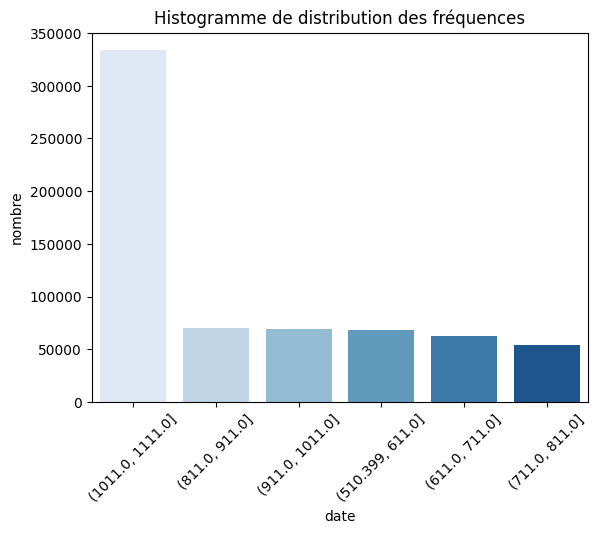

In [25]:
# plot
df_order_date = df_user_log.loc[df_user_log['action_type']=='order', ['date']].date.value_counts(bins=6).reset_index()
sns.barplot(x=df_order_date['index'], y=df_order_date['date'], data=df_order_date, palette='Blues')
plt.xticks(rotation=45)
plt.title('Histogramme de distribution des fréquences')
plt.xlabel('date')
plt.ylabel('nombre')
plt.show()

Order activity is mainly concentrated between October and November.

-----

### Analysis of Ordering Behavior During Different Time Periods Within a Day

In [26]:
df_user_log["time_hours_view"] = df_user_log.apply(lambda x:x["timestamp"]/3600, axis=1)
df_user_log

,user_id,item_id,cat_id,seller_id,brand_id,date,action_type,timestamp,age_range,gender,time_hours_view
0,328862,323294,833,2882,2661.0,829,click,62242.300959,6.0,1.0,17.289528
1,328862,623866,1271,2882,2661.0,829,click,75598.841378,6.0,1.0,20.999678
2,328862,239288,602,420,4953.0,801,click,69606.479645,6.0,1.0,19.335133
3,328862,197239,602,420,4953.0,801,click,62758.912202,6.0,1.0,17.433031
4,328862,524981,664,2382,1272.0,602,click,39651.123222,6.0,1.0,11.014201
...,...,...,...,...,...,...,...,...,...,...,...
10985061,208016,869502,898,3716,5508.0,1110,click,58128.784724,NaN,NaN,16.146885
10985062,208016,51712,898,3763,8434.0,1110,click,84907.294322,NaN,NaN,23.585360
10985063,208016,952056,898,3763,8434.0,1110,click,64118.247166,NaN,NaN,17.810624
10985064,208016,952056,898,3763,8434.0,1110,click,18877.391838,NaN,NaN,5.243720


In [27]:
df_user_log.loc[df_user_log["action_type"]=="order", ["time_hours_view"]].time_hours_view.value_counts(bins=12)

(20.0, 22.0]     94209
(22.0, 24.0]     91529
(18.0, 20.0]     91330
(16.0, 18.0]     85681
(14.0, 16.0]     75372
(12.0, 14.0]     63580
(10.0, 12.0]     50909
(8.0, 10.0]      38938
(6.0, 8.0]       27962
(4.0, 6.0]       19428
(2.0, 4.0]       12639
(-0.025, 2.0]     8000
Name: time_hours_view, dtype: int64

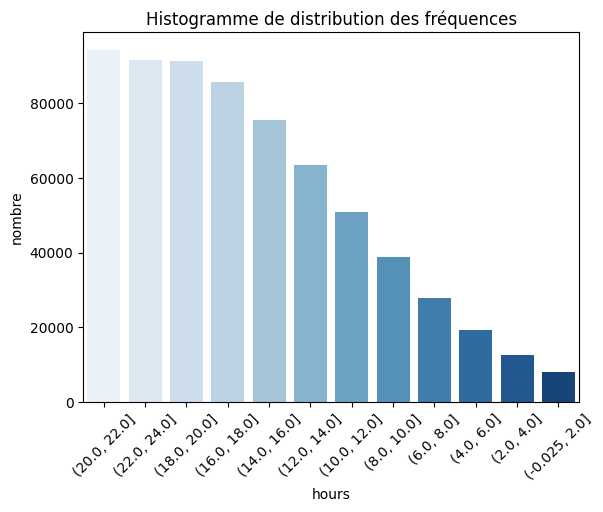

In [28]:
# plot
df_order_hours = df_user_log.loc[df_user_log["action_type"]=="order", ["time_hours_view"]].time_hours_view.value_counts(bins=12).reset_index()
sns.barplot(x=df_order_hours['index'], y=df_order_hours['time_hours_view'], data=df_order_hours, palette='Blues')
plt.xticks(rotation=45)
plt.title('Histogramme de distribution des fréquences')
plt.xlabel('hours')
plt.ylabel('nombre')
plt.show()

We should target women aged 25–34 and send bulk SMS messages between 8 PM and 10 PM in mid to late October. This approach is expected to yield the best conversion rates.

# Part 2

## Step 1 Data Cleaning

In [29]:
df_user_log = pd.read_csv('user_behavior_time_resampled.csv')
df_user_log

,user_id,item_id,cat_id,seller_id,brand_id,time_stamp,action_type,timestamp
0,328862,323294,833,2882,2661.0,829,click,62242.300959
1,328862,623866,1271,2882,2661.0,829,click,75598.841378
2,328862,239288,602,420,4953.0,801,click,69606.479645
3,328862,197239,602,420,4953.0,801,click,62758.912202
4,328862,524981,664,2382,1272.0,602,click,39651.123222
...,...,...,...,...,...,...,...,...
10985061,208016,869502,898,3716,5508.0,1110,click,58128.784724
10985062,208016,51712,898,3763,8434.0,1110,click,84907.294322
10985063,208016,952056,898,3763,8434.0,1110,click,64118.247166
10985064,208016,952056,898,3763,8434.0,1110,click,18877.391838


In [30]:
df_user_log.isnull().sum()

user_id            0
item_id            0
cat_id             0
seller_id          0
brand_id       18132
time_stamp         0
action_type        0
timestamp          0
dtype: int64

In [31]:
df_user_log["action_type"].value_counts()

click    9709458
order     659577
fav       600738
cart       15293
Name: action_type, dtype: int64

## Step 2 Select features for regression analysis.

Five features that may affect product sales:
1. Products\
    1.1 Click Count\
    1.2 Add-to-Cart Count\
    1.3 Favorite Count
2. Stores\
    2.1 Number of Products in the Store\
    2.2 Number of VIP Customers of the Store

### Calculation of Product Features

In [32]:
df_user_log["click"] = df_user_log.action_type.apply(lambda l:1 if l=="click" else 0)
df_user_log["cart"] = df_user_log.action_type.apply(lambda l:1 if l=="cart" else 0)
df_user_log["order"] = df_user_log.action_type.apply(lambda l:1 if l=="order" else 0)
df_user_log["fav"] = df_user_log.action_type.apply(lambda l:1 if l=="fav" else 0)
df_user_log

,user_id,item_id,cat_id,seller_id,brand_id,time_stamp,action_type,timestamp,click,cart,order,fav
0,328862,323294,833,2882,2661.0,829,click,62242.300959,1,0,0,0
1,328862,623866,1271,2882,2661.0,829,click,75598.841378,1,0,0,0
2,328862,239288,602,420,4953.0,801,click,69606.479645,1,0,0,0
3,328862,197239,602,420,4953.0,801,click,62758.912202,1,0,0,0
4,328862,524981,664,2382,1272.0,602,click,39651.123222,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
10985061,208016,869502,898,3716,5508.0,1110,click,58128.784724,1,0,0,0
10985062,208016,51712,898,3763,8434.0,1110,click,84907.294322,1,0,0,0
10985063,208016,952056,898,3763,8434.0,1110,click,64118.247166,1,0,0,0
10985064,208016,952056,898,3763,8434.0,1110,click,18877.391838,1,0,0,0


In [33]:
print("Distribution of click:\n",df_user_log.click.value_counts())
print("Distribution of cart:\n",df_user_log.cart.value_counts())
print("Distribution of order:\n",df_user_log.order.value_counts())
print("Distribution of fav:\n",df_user_log.fav.value_counts())

Distribution of click:
 1    9709458
0    1275608
Name: click, dtype: int64
Distribution of cart:
 0    10969773
1       15293
Name: cart, dtype: int64
Distribution of order:
 0    10325489
1      659577
Name: order, dtype: int64
Distribution of fav:
 0    10384328
1      600738
Name: fav, dtype: int64


In [34]:
# Selection of Behavioral Features
df_clean = df_user_log[["item_id", "click", "cart", "order", "fav"]]
df_clean

,item_id,click,cart,order,fav
0,323294,1,0,0,0
1,623866,1,0,0,0
2,239288,1,0,0,0
3,197239,1,0,0,0
4,524981,1,0,0,0
...,...,...,...,...,...
10985061,869502,1,0,0,0
10985062,51712,1,0,0,0
10985063,952056,1,0,0,0
10985064,952056,1,0,0,0


In [35]:
df_item = df_clean.groupby(["item_id"]).sum()
df_item

,click,cart,order,fav
item_id,,,,
2,511,0,67,60
3,22,0,2,1
4,5,0,0,0
7,1,0,0,0
8,11,0,3,0
...,...,...,...,...
1113160,0,0,1,0
1113161,1,0,0,0
1113162,17,0,2,1


### Calculation of Stores Features

In [36]:
df_vip_user = pd.read_csv('vip_user.csv')
df_vip_user

,user_id,merchant_id,label
0,34176,3906,0
1,34176,121,0
2,34176,4356,1
3,34176,2217,0
4,230784,4818,0
...,...,...,...
260859,359807,4325,0
260860,294527,3971,0
260861,294527,152,0
260862,294527,2537,0


In [37]:
# Calculate the number of VIP users for each merchant.
df_vip_user = df_vip_user.rename(columns={"merchant_id":"seller_id"})
df_brand_vip_users = df_vip_user[["seller_id", "label"]].groupby("seller_id").sum()
df_brand_vip_users

,label
seller_id,
2,2
8,1
9,1
10,16
13,15
...,...
4987,0
4988,2
4991,0


In [38]:
# Calculate the number of products for each store.
df_seller_item_count = df_user_log[["seller_id", "item_id"]]
df_seller_item_count = df_seller_item_count.drop_duplicates("item_id")
df_seller_item_count["item_id"] = 1
df_seller_item_count = df_seller_item_count.groupby('seller_id').sum()
df_seller_item_count = df_seller_item_count.rename(columns = {"item_id":"item_count"})
df_seller_item_count

,item_count
seller_id,
1,2547
2,96
3,87
4,96
5,309
...,...
4991,14
4992,87
4993,147


In [39]:
# Associate product features with store features.
df_brand_item_map = df_user_log[['item_id', 'seller_id']]
df_brand_item_map = df_brand_item_map.drop_duplicates('item_id')
df_item = df_item.merge(df_brand_item_map, how='left', on='item_id')
df_item

,item_id,click,cart,order,fav,seller_id
0,2,511,0,67,60,1381
1,3,22,0,2,1,2705
2,4,5,0,0,0,4007
3,7,1,0,0,0,1640
4,8,11,0,3,0,2592
...,...,...,...,...,...,...
756720,1113160,0,0,1,0,3825
756721,1113161,1,0,0,0,1543
756722,1113162,17,0,2,1,2586
756723,1113163,5,0,0,1,2654


In [40]:
# Join the store VIP user feature table with the product feature table.
df_item = df_item.merge(df_brand_vip_users, how='left', on='seller_id')
df_item

,item_id,click,cart,order,fav,seller_id,label
0,2,511,0,67,60,1381,NaN
1,3,22,0,2,1,2705,NaN
2,4,5,0,0,0,4007,3.0
3,7,1,0,0,0,1640,2.0
4,8,11,0,3,0,2592,16.0
...,...,...,...,...,...,...,...
756720,1113160,0,0,1,0,3825,1.0
756721,1113161,1,0,0,0,1543,0.0
756722,1113162,17,0,2,1,2586,NaN
756723,1113163,5,0,0,1,2654,3.0


In [41]:
# Fill missing values with 0.
df_item["label"] = df_item["label"].fillna(0)
df_item

,item_id,click,cart,order,fav,seller_id,label
0,2,511,0,67,60,1381,0.0
1,3,22,0,2,1,2705,0.0
2,4,5,0,0,0,4007,3.0
3,7,1,0,0,0,1640,2.0
4,8,11,0,3,0,2592,16.0
...,...,...,...,...,...,...,...
756720,1113160,0,0,1,0,3825,1.0
756721,1113161,1,0,0,0,1543,0.0
756722,1113162,17,0,2,1,2586,0.0
756723,1113163,5,0,0,1,2654,3.0


In [42]:
df_item = df_item.merge(df_seller_item_count, how="left", on = 'seller_id')
df_item

,item_id,click,cart,order,fav,seller_id,label,item_count
0,2,511,0,67,60,1381,0.0,181
1,3,22,0,2,1,2705,0.0,70
2,4,5,0,0,0,4007,3.0,16
3,7,1,0,0,0,1640,2.0,80
4,8,11,0,3,0,2592,16.0,197
...,...,...,...,...,...,...,...,...
756720,1113160,0,0,1,0,3825,1.0,461
756721,1113161,1,0,0,0,1543,0.0,298
756722,1113162,17,0,2,1,2586,0.0,175
756723,1113163,5,0,0,1,2654,3.0,411


### Regression Analysis

In [43]:
X = df_item.drop(columns=["order", "seller_id", "item_id"])
y = df_item["order"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train

,click,cart,fav,label,item_count
260577,1,0,0,3.0,84
314027,2,0,0,0.0,266
154884,18,0,1,2.0,102
515741,24,0,1,207.0,3304
18269,2,0,1,29.0,953
...,...,...,...,...,...
259178,2,0,0,0.0,98
365838,3,0,0,0.0,230
131932,13,0,0,0.0,1418
671155,22,0,0,0.0,235


In [44]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

## Correlation
print("Scores:",linear_model.score(X_test,y_test))
## Mean Absolute Error
print("MAE:", mean_absolute_error(y_test, y_pred))

print("intercept", linear_model.intercept_)
print("coef_:", linear_model.coef_)

Scores: 0.4417000916368723
MAE: 0.9939945446527991
intercept 0.3249010575476352
coef_: [-1.09570715e-03  7.64421017e+00  7.20958736e-01  6.07684870e-04
 -3.10573289e-04]


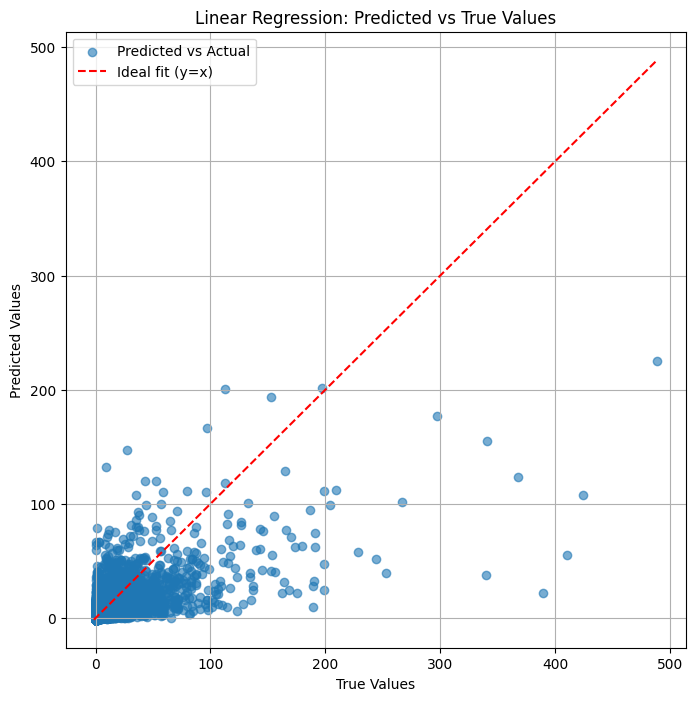

In [45]:
y_true = y_test.values.ravel() if hasattr(y_test, "values") else y_test
y_pred_arr = y_pred.ravel() if hasattr(y_pred, "ravel") else y_pred

plt.figure(figsize=(8, 8))
plt.scatter(y_true, y_pred_arr, alpha=0.6, label='Predicted vs Actual')


lims = [
    np.min([y_true.min(), y_pred_arr.min()]),  
    np.max([y_true.max(), y_pred_arr.max()])   
]
plt.plot(lims, lims, 'r--', label='Ideal fit (y=x)')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Linear Regression: Predicted vs True Values')
plt.legend()
plt.grid(True)
plt.show()